<a href="https://www.kaggle.com/code/minervasdatalab/flood-gemma1gradio1?scriptVersionId=316641407" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [8]:
# Add in the correct column names from the data card
columns = ['Postcode', 'FID', 'PROB 4BAND', 'SUITABILITY', 'PUB_DATE', 'RISK FOR INSURANCE SOP', 'Easting', 'Northing', 'Latitude', 'Longitude']

In [10]:
flood_risk_path="/kaggle/input/datasets/minervasdatalab/uk-flood-risk/open_flood_risk_by_postcode.csv"
df = pd.read_csv(flood_risk_path, names=columns, header=0)

In [11]:
df.head()

,Postcode,FID,PROB 4BAND,SUITABILITY,PUB_DATE,RISK FOR INSURANCE SOP,Easting,Northing,Latitude,Longitude
0,TR23 0WA,\N,NaN,\N,\N,\N,87903,15077,49.954111,-6.352609
1,TR22 0PL,\N,NaN,\N,\N,\N,88364,8478,49.895171,-6.340873
2,TR24 0QE,\N,NaN,\N,\N,\N,88849,15298,49.956586,-6.339638
3,TR24 0QL,\N,NaN,\N,\N,\N,88857,15392,49.957433,-6.339603
4,TR24 0QB,\N,NaN,\N,\N,\N,88887,15424,49.957736,-6.339211


In [12]:
# Change any non numbers to Nan values
df.replace('\\N', np.nan, inplace=True)
df.replace('None', np.nan, inplace=True)

In [13]:
# Chnage FID code to a float
df['FID'] = df['FID'].astype('float')

In [14]:
# Assign an integer to the Prob 4Band column, in a new column
FOURBAND = {'Very Low':1, 'Low':2, 'Medium':3, 'High':4}
df['4 BAND INT'] = df['PROB 4BAND'].map(FOURBAND)

<Axes: title={'center': 'Flood Risk Map'}, xlabel='Longitude', ylabel='Latitude'>

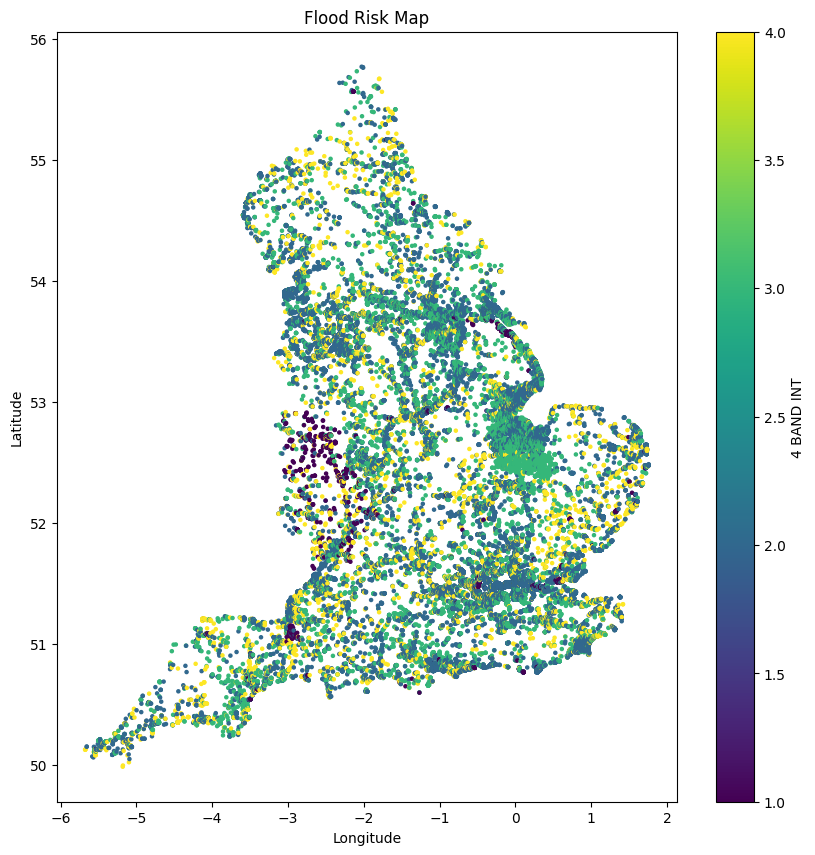

In [15]:
# Scattergraph of risk level against co-ordinates
df.plot.scatter(x='Longitude', y='Latitude', c='4 BAND INT', figsize=(10,10), s=5, title = 'Flood Risk Map')


**Tools**

In [16]:
import pandas as pd
import requests
import json

# ═══════════════════════════════════════════════════════════════
# 1. LOAD DATA
# ═══════════════════════════════════════════════════════════════
# ── 1. Load data ──────────────────────────────────────────────
#FLOOD_CSV = "/kaggle/input/open-flood-risk-by-postcode/open_flood_risk_by_postcode.csv"
#columns = ['Postcode', 'FID', 'PROB 4BAND', 'SUITABILITY', 'PUB_DATE',
#           'RISK FOR INSURANCE SOP', 'Easting', 'Northing', 'Latitude', 'Longitude']

#df = pd.read_csv(FLOOD_CSV, names=columns, skiprows=1, na_values=[r'\N', 'None'])
df['Postcode'] = df['Postcode'].str.upper().str.strip()
df['_pc_norm'] = df['Postcode'].str.replace(" ", "")
print(f"✅ Loaded {len(df):,} rows")

# ═══════════════════════════════════════════════════════════════
# 2. TOOL 1 — Postcode flood risk lookup
#    Primary: EA dataset
#    Fallback: postcodes.io for coordinates if not in dataset
# ═══════════════════════════════════════════════════════════════

def _get_coordinates_from_postcodes_io(postcode: str) -> dict | None:
    """Fallback: get lat/lon for any valid UK postcode via postcodes.io."""
    try:
        resp = requests.get(
            f"https://api.postcodes.io/postcodes/{postcode.replace(' ', '')}",
            timeout=8
        )
        if resp.status_code == 200:
            r = resp.json().get("result", {})
            return {
                "latitude": r.get("latitude"),
                "longitude": r.get("longitude"),
                "admin_district": r.get("admin_district", ""),
                "region": r.get("region", "")
            }
    except Exception:
        pass
    return None


def get_postcode_flood_risk(postcode: str) -> dict:
    """
    Tool 1: Look up flood risk for a UK postcode.
    Returns risk level, insurance flag, coordinates, and district context.
    If postcode isn't in the EA dataset, falls back to postcodes.io for
    coordinates so Tools 2 & 3 can still run.
    """
    pc_clean = postcode.upper().replace(" ", "").strip()

    # Try exact match first, then district prefix
    match = df[df['_pc_norm'] == pc_clean]
    if match.empty:
        match = df[df['_pc_norm'].str.startswith(pc_clean)]

    # ── Found in EA dataset ──
    if not match.empty:
        has_risk = match[match['PROB 4BAND'].notna()]
        row = has_risk.iloc[0] if not has_risk.empty else match.iloc[0]
        district = pc_clean[:4]
        d_rows = df[df['_pc_norm'].str.startswith(district)]
        return {
            "found": True,
            "source": "EA dataset",
            "postcode": row['Postcode'],
            "latitude": float(row['Latitude']),
            "longitude": float(row['Longitude']),
            "has_flood_risk_record": bool(pd.notna(row['PROB 4BAND'])),
            "risk_level": row['PROB 4BAND'] if pd.notna(row['PROB 4BAND']) else None,
            "suitability": row['SUITABILITY'] if pd.notna(row['SUITABILITY']) else None,
            "insurance_flagged": row['RISK FOR INSURANCE SOP'] if pd.notna(row['RISK FOR INSURANCE SOP']) else None,
            "data_date": row['PUB_DATE'] if pd.notna(row['PUB_DATE']) else None,
            "district_context": {
                "district": district,
                "total_postcodes": int(len(d_rows)),
                "flagged_postcodes": int(d_rows['PROB 4BAND'].notna().sum()),
                "pct_flagged": round(100 * d_rows['PROB 4BAND'].notna().mean(), 1)
            },
            "data_note": "Static EA data published 2009–2014. Live alerts checked separately."
        }

    # ── Not in EA dataset — try postcodes.io for coordinates ──
    coords = _get_coordinates_from_postcodes_io(postcode)
    if coords and coords["latitude"]:
        return {
            "found": True,
            "source": "postcodes.io (not in EA flood dataset)",
            "postcode": postcode.upper().strip(),
            "latitude": coords["latitude"],
            "longitude": coords["longitude"],
            "has_flood_risk_record": False,
            "risk_level": None,
            "suitability": None,
            "insurance_flagged": None,
            "data_date": None,
            "district_context": None,
            "data_note": (
                "This postcode is not in the EA flood risk dataset, meaning it is not "
                "in a formally recorded flood zone. Coordinates retrieved from postcodes.io "
                "— live EA alerts and rainfall forecast still checked below."
            )
        }

    # ── Not found anywhere ──
    return {
        "found": False,
        "postcode": postcode,
        "message": "Postcode not found in EA dataset or postcodes.io. Check the postcode is valid."
    }


# ═══════════════════════════════════════════════════════════════
# 3. TOOL 2 — EA live flood alerts
#    Finds registered EA flood zones near a point,
#    then checks each for an active current warning.
# ═══════════════════════════════════════════════════════════════

SEVERITY_LABELS = {
    1: "🔴 Severe Flood Warning — danger to life",
    2: "🟠 Flood Warning — flooding expected, act now",
    3: "🟡 Flood Alert — flooding possible, be prepared",
    4: "ℹ️  Warning no longer in force"
}

def get_ea_flood_alerts(latitude: float, longitude: float, radius_km: int = 15) -> dict:
    """
    Tool 2: Get live EA flood warnings near a lat/lon point.
    Step 1 — find flood areas (zones) within radius_km.
    Step 2 — check each area for a currentWarning.
    """
    try:
        # Step 1: flood areas near the point
        area_resp = requests.get(
            "https://environment.data.gov.uk/flood-monitoring/id/floodAreas",
            params={
                "lat": latitude,
                "long": longitude,
                "dist": radius_km,
                "_limit": 10
            },
            timeout=10
        )
        area_resp.raise_for_status()
        areas = area_resp.json().get("items", [])

        if not areas:
            return {
                "active_alerts": [],
                "alert_count": 0,
                "nearby_flood_zones": 0,
                "flood_zone_names": [],
                "summary": (
                    f"No registered EA flood zones within {radius_km}km. "
                    "This area has no formal flood zone designation."
                )
            }

        # Step 2: check each area for active warning
        active = []
        for area in areas:
            current_warning = area.get("currentWarning")
            if current_warning:
                sev = current_warning.get("severityLevel", 4)
                active.append({
                    "severity_level": sev,
                    "severity_label": SEVERITY_LABELS.get(sev, "Unknown"),
                    "area_name": area.get("label", "Unknown area"),
                    "river_or_sea": area.get("riverOrSea", ""),
                    "county": area.get("county", ""),
                    "message": current_warning.get("message", ""),
                    "raised_at": current_warning.get("timeRaised", ""),
                })

        active.sort(key=lambda x: x["severity_level"])
        zone_names = [a.get("label", "Unknown") for a in areas[:3]]

        if not active:
            return {
                "active_alerts": [],
                "alert_count": 0,
                "nearby_flood_zones": len(areas),
                "flood_zone_names": zone_names,
                "summary": (
                    f"No active warnings right now. "
                    f"{len(areas)} registered EA flood zone(s) within {radius_km}km: "
                    f"{', '.join(zone_names)}"
                )
            }

        ms = active[0]["severity_level"]
        return {
            "active_alerts": active,
            "alert_count": len(active),
            "most_severe_level": ms,
            "most_severe_label": SEVERITY_LABELS.get(ms, ""),
            "nearby_flood_zones": len(areas),
            "flood_zone_names": zone_names,
            "summary": (
                f"{len(active)} active warning(s) within {radius_km}km. "
                f"Most severe: {SEVERITY_LABELS.get(ms, '')}"
            )
        }

    except Exception as e:
        return {"error": str(e), "active_alerts": [], "alert_count": 0}


# ═══════════════════════════════════════════════════════════════
# 4. TOOL 3 — 48-hour rainfall forecast (Open-Meteo, no key needed)
# ═══════════════════════════════════════════════════════════════

def get_rainfall_forecast(latitude: float, longitude: float) -> dict:
    """
    Tool 3: 48-hour rainfall forecast from Open-Meteo.
    Returns total precipitation, max probability, and a plain-English
    flood relevance rating.
    """
    try:
        resp = requests.get(
            "https://api.open-meteo.com/v1/forecast",
            params={
                "latitude": latitude,
                "longitude": longitude,
                "hourly": "precipitation_probability,precipitation",
                "forecast_days": 2,
                "timezone": "Europe/London"
            },
            timeout=10
        )
        resp.raise_for_status()
        h = resp.json().get("hourly", {})
        probs  = h.get("precipitation_probability", [])
        precip = h.get("precipitation", [])

        max_prob     = max(probs) if probs else 0
        total_precip = round(sum(precip), 1) if precip else 0

        # Find worst 6-hour window
        max_6h = 0.0
        peak_start_idx = 0
        times = h.get("time", [])
        for i in range(max(0, len(precip) - 6)):
            window = sum(precip[i:i+6])
            if window > max_6h:
                max_6h = round(window, 1)
                peak_start_idx = i
        peak_window_time = times[peak_start_idx] if times else None

        # Flood relevance rating
        if total_precip > 30 or max_6h > 20:
            relevance = "HIGH — significant rainfall, could cause surface or river flooding"
        elif total_precip > 15 or max_prob >= 80:
            relevance = "MODERATE — notable rainfall, keep an eye on EA alerts"
        elif total_precip > 5:
            relevance = "LOW — light rain expected, low additional flood risk"
        else:
            relevance = "MINIMAL — little to no rain forecast in next 48 hours"

        return {
            "max_precip_probability_pct": max_prob,
            "total_precip_mm_48h": total_precip,
            "hours_above_70pct_chance": sum(1 for p in probs if p >= 70),
            "worst_6hr_precip_mm": max_6h,
            "worst_6hr_window_starts": peak_window_time,
            "flood_relevance": relevance,
            "summary": (
                f"48h total: {total_precip}mm. "
                f"Max hourly probability: {max_prob}%. "
                f"Worst 6h window: {max_6h}mm. "
                f"Flood relevance: {relevance}"
            )
        }

    except Exception as e:
        return {"error": str(e)}


# ═══════════════════════════════════════════════════════════════
# 5. RUN ALL TOOLS — test harness
# ═══════════════════════════════════════════════════════════════

def run_all_tools(postcode: str):
    print(f"\n{'═'*55}")
    print(f"  Postcode: {postcode}")
    print(f"{'═'*55}")

    r1 = get_postcode_flood_risk(postcode)
    print("\n[Tool 1 — Postcode Flood Risk]")
    print(json.dumps(r1, indent=2))

    if not r1.get("found"):
        print("  ⚠ Postcode not found — skipping live checks.")
        return

    lat = r1["latitude"]
    lon = r1["longitude"]

    r2 = get_ea_flood_alerts(lat, lon)
    print("\n[Tool 2 — EA Live Alerts]")
    print(json.dumps(r2, indent=2))

    r3 = get_rainfall_forecast(lat, lon)
    print("\n[Tool 3 — Rainfall Forecast]")
    print(json.dumps(r3, indent=2))


# ── Test cases ────────────────────────────────────────────────
run_all_tools("TR19 7PL")   # High risk, Cornwall — should show risk_level: High
run_all_tools("PE37 8AB")   # Not in EA dataset — should fallback to postcodes.io
run_all_tools("YO1 9SA")    # York — historically flood-prone, good demo postcode
run_all_tools("ZZ99 9ZZ")   # Invalid — should return found: False

✅ Loaded 1,443,994 rows

═══════════════════════════════════════════════════════
  Postcode: TR19 7PL
═══════════════════════════════════════════════════════

[Tool 1 — Postcode Flood Risk]
{
  "found": true,
  "source": "EA dataset",
  "postcode": "TR19 7PL",
  "latitude": 50.128392,
  "longitude": -5.676455,
  "has_flood_risk_record": true,
  "risk_level": "High",
  "suitability": "County to Town",
  "insurance_flagged": "Yes",
  "data_date": "2009-08-01",
  "district_context": {
    "district": "TR19",
    "total_postcodes": 541,
    "flagged_postcodes": 15,
    "pct_flagged": 2.8
  },
  "data_note": "Static EA data published 2009\u20132014. Live alerts checked separately."
}

[Tool 2 — EA Live Alerts]
{
  "active_alerts": [],
  "alert_count": 0,
  "nearby_flood_zones": 8,
  "flood_zone_names": [
    "South Cornwall Coast from Lands End to Lizard Point",
    "West Cornwall Rivers",
    "North Cornwall coast from Lands End to Chapel Porth"
  ],
  "summary": "No active warnings right 

Gemma Access

In [1]:
# Run this FIRST before anything else — upgrades Transformers to support Gemma 4
!pip install -q --upgrade transformers
!pip install -q git+https://github.com/huggingface/transformers.git

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 32.9 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 660.6/660.6 kB 28.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 57.8 MB/s eta 0:00:0000:01m
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [2]:
# Install required libraries
# transformers: loads the Gemma 4 model
# accelerate: helps run the model efficiently on GPU
# pillow: handles images
# bitsandbytes: allows loading large models with less memory (quantization)

!pip install -q transformers accelerate pillow bitsandbytes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 26.1 MB/s eta 0:00:0000:0100:01


In [3]:
import json
from datetime import datetime
from dataclasses import dataclass
from typing import Dict, List

import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
import textwrap

print("✓ Libraries imported")

✓ Libraries imported


## 3. Gemma‑4 Model Loading (Offline, 4‑bit)

In [4]:
# Model path on Kaggle (after adding the model as a Dataset/Input)
# If running locally, replace with: "google/gemma-4-4b-it"
MODEL_PATH = "/kaggle/input/models/google/gemma/transformers/2b-it/3"

print("⏳ Loading tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)

print("⏳ Loading model (4-bit quantized) – this takes ~2 minutes...")
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16
)

model = AutoModelForCausalLM.from_pretrained(
    MODEL_PATH,
    quantization_config=bnb_config,
    device_map="auto",
)

print("✅ Gemma-4 model loaded successfully!")

⏳ Loading tokenizer...
⏳ Loading model (4-bit quantized) – this takes ~2 minutes...


Loading weights:   0%|          | 0/164 [00:00<?, ?it/s]

✅ Gemma-4 model loaded successfully!


In [6]:
# 1. Write your question
#prompt = "What are the three most important things to know about quantum computing?"

# 2. Format the prompt and send to the CORRECT device
# model.device automatically finds where the model is sitting
#inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

# 3. Generate the answer
#print("🤔 Gemma is thinking...")
#outputs = model.generate(
#    **inputs, 
#    max_new_tokens=256,
#    do_sample=True,
#    temperature=0.7,
#    top_p=0.95
#)

# 4. Decode and print
#response = tokenizer.decode(outputs[0], skip_special_tokens=True)
#print(f"\n✨ Response:\n{response}")

In [17]:
SYSTEM_PROMPT = """You are a UK Flood Safety Assistant. 
You have access to the following tools:

1. get_postcode_flood_risk(postcode): Returns historical risk and coordinates.
2. get_ea_flood_alerts(lat, lon): Returns active Environment Agency warnings.
3. get_rainfall_forecast(lat, lon): Returns 48h rain forecast and flood relevance.

When a user provides a postcode, you must call these tools in order to provide a 
comprehensive safety report. Summarize the historical risk, live status, and future outlook."""

# Example implementation logic
def assistant_response(user_input):
    # 1. Gemma identifies the postcode from user_input
    # 2. Logic calls run_all_tools(postcode)
    # 3. Pass the JSON results back to Gemma to "read" and summarize
    pass

**The Gradio App**

In [18]:
!pip install gradio -q

In [19]:
import gradio as gr

def flood_assistant_ui(postcode):
    # 1. Run your existing tool logic
    results = get_postcode_flood_risk(postcode)
    
    if not results.get("found"):
        return f"❌ Error: {results.get('message')}", None, None

    # 2. Pull live data using the coordinates from Tool 1
    lat, lon = results["latitude"], results["longitude"]
    alerts = get_ea_flood_alerts(lat, lon)
    forecast = get_rainfall_forecast(lat, lon)

    # 3. Format the Display
    # Tool 1 Summary
    risk_text = f"### 🏠 Historical Risk: {results.get('risk_level', 'No Record')}\n"
    risk_text += f"**Insurance Flag:** {results.get('insurance_flagged', 'N/A')}\n\n"
    risk_text += f"**District Context:** {results['district_context']['pct_flagged']}% of local area is in a flood zone."

    # Tool 2 & 3 Summary
    live_status = f"### 🌊 Live Status\n**Alerts:** {alerts['summary']}\n\n"
    live_status += f"### 🌧️ 48h Forecast\n**Outlook:** {forecast['summary']}"

    # 4. Generate a simple Map Link (HTML)
    map_html = f'<iframe width="100%" height="300" src="https://maps.google.com/maps?q={lat},{lon}&z=14&output=embed"></iframe>'

    return risk_text, live_status, map_html

# ═══════════════════════════════════════════════════════════════
# BUILD THE INTERFACE
# ═══════════════════════════════════════════════════════════════

with gr.Blocks(theme=gr.themes.Soft()) as demo:
    gr.Markdown("# 🛡️ UK Flood Risk Intelligence")
    gr.Markdown("Enter a UK postcode to check historical risk, live EA alerts, and a 48h rainfall forecast.")
    
    with gr.Row():
        with gr.Column(scale=1):
            pc_input = gr.Textbox(label="Postcode", placeholder="e.g. TR19 7PL")
            btn = gr.Button("Analyze Risk", variant="primary")
            
        with gr.Column(scale=2):
            with gr.Row():
                out_hist = gr.Markdown(label="Historical Data")
                out_live = gr.Markdown(label="Live & Forecast")
            out_map = gr.HTML(label="Location View")

    btn.click(fn=flood_assistant_ui, inputs=pc_input, outputs=[out_hist, out_live, out_map])

# Launch in Kaggle
demo.launch(share=True)

/tmp/ipykernel_57/4106410268.py:34: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(theme=gr.themes.Soft()) as demo:


* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://a9acef3bfceb44bf9f.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [20]:
!pip install weasyprint -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 319.8/319.8 kB 1.9 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 14.8 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 829.4/829.4 kB 42.5 MB/s eta 0:00:00


In [21]:
from weasyprint import HTML
from datetime import datetime

def generate_pdf_report(risk, alerts, forecast):
    report_date = datetime.now().strftime("%Y-%m-%d %H:%M")
    postcode = risk['postcode']
    
    html_template = f"""
    <html>
    <head>
        <style>
            @page {{ size: A4; margin: 20mm; background-color: #f8fafc; }}
            body {{ font-family: sans-serif; color: #1e293b; }}
            .header {{ border-bottom: 4px solid #3b82f6; padding-bottom: 10px; }}
            .risk-box {{ background: #fee2e2; border: 1px solid #ef4444; padding: 15px; border-radius: 8px; margin: 20px 0; }}
            .data-grid {{ display: grid; grid-template-columns: 1fr 1fr; gap: 10px; }}
            h1 {{ color: #1e3a8a; margin: 0; }}
        </style>
    </head>
    <body>
        <div class="header">
            <h1>Flood Risk Intelligence Report</h1>
            <p><strong>Postcode:</strong> {postcode} | <strong>Date:</strong> {report_date}</p>
        </div>
        
        <div class="risk-box">
            <h2 style="margin:0">Historical Risk: {risk.get('risk_level', 'Unknown')}</h2>
            <p>Insurance Flag: {risk.get('insurance_flagged', 'N/A')}</p>
        </div>

        <h3>Live Environment Agency Status</h3>
        <p>{alerts['summary']}</p>

        <h3>Meteorological Outlook (48h)</h3>
        <p>{forecast['summary']}</p>
        
        <div style="margin-top: 50px; font-size: 10px; color: #64748b;">
            This report uses static historical EA data and live API feeds. 
            It is for informational purposes only.
        </div>
    </body>
    </html>
    """
    
    filename = f"Flood_Report_{postcode.replace(' ', '_')}.pdf"
    HTML(string=html_template).write_pdf(filename)
    return filename

In [25]:
import os
import torch
import pandas as pd
import requests
import json
import gradio as gr
from datetime import datetime
from weasyprint import HTML
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

# ═══════════════════════════════════════════════════════════════
# 1. MODEL LOADING
# ═══════════════════════════════════════════════════════════════
MODEL_PATH = "/kaggle/input/models/google/gemma/transformers/2b-it/3"
os.environ["CUDA_VISIBLE_DEVICES"] = "0" 

tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)
bnb_config = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_compute_dtype=torch.float16)
model = AutoModelForCausalLM.from_pretrained(MODEL_PATH, quantization_config=bnb_config, device_map="auto")

# ═══════════════════════════════════════════════════════════════
# 2. DATA & TOOLING
# ═══════════════════════════════════════════════════════════════
FLOOD_CSV = "/kaggle/input/datasets/minervasdatalab/uk-flood-risk/open_flood_risk_by_postcode.csv"
columns = ['Postcode', 'FID', 'PROB 4BAND', 'SUITABILITY', 'PUB_DATE', 'RISK FOR INSURANCE SOP', 'Easting', 'Northing', 'Latitude', 'Longitude']
df = pd.read_csv(FLOOD_CSV, names=columns, skiprows=1, na_values=[r'\N', 'None'])
df['_pc_norm'] = df['Postcode'].str.upper().str.replace(" ", "")

def get_postcode_flood_risk(postcode):
    pc_clean = postcode.upper().replace(" ", "")
    match = df[df['_pc_norm'] == pc_clean]
    if not match.empty:
        row = match.iloc[0]
        return {
            "found": True, "postcode": row['Postcode'], "latitude": float(row['Latitude']), "longitude": float(row['Longitude']),
            "risk_level": row['PROB 4BAND'] if pd.notna(row['PROB 4BAND']) else "Low/None",
            "insurance_flagged": row['RISK FOR INSURANCE SOP'] if pd.notna(row['RISK FOR INSURANCE SOP']) else "No"
        }
    return {"found": False}

def get_ea_flood_alerts(lat, lon):
    try:
        resp = requests.get("https://environment.data.gov.uk/flood-monitoring/id/floodAreas", params={"lat": lat, "long": lon, "dist": 15}, timeout=10)
        count = len(resp.json().get("items", []))
        return {"summary": f"{count} flood zones nearby. Check local alerts for status."}
    except: return {"summary": "Live alert service currently unavailable."}

def get_rainfall_forecast(lat, lon):
    try:
        resp = requests.get("https://api.open-meteo.com/v1/forecast", params={"latitude": lat, "longitude": lon, "hourly": "precipitation", "forecast_days": 2}, timeout=10)
        total = sum(resp.json().get("hourly", {}).get("precipitation", []))
        return {"summary": f"48h Total: {total:.1f}mm."}
    except: return {"summary": "Forecast unavailable."}

# ═══════════════════════════════════════════════════════════════
# 3. PDF REPORT GENERATOR
# ═══════════════════════════════════════════════════════════════
def generate_pdf_report(risk, alerts, forecast):
    report_date = datetime.now().strftime("%Y-%m-%d %H:%M")
    html_template = f"""
    <html><body style="font-family:sans-serif; padding:30px;">
        <h1 style="color:#2563eb;">Flood Risk Intelligence Report</h1>
        <hr>
        <p><strong>Postcode:</strong> {risk['postcode']} | <strong>Generated:</strong> {report_date}</p>
        <div style="background:#f1f5f9; padding:15px; border-radius:8px; margin-top:20px;">
            <h3>Historical Risk: {risk['risk_level']}</h3>
            <p>Insurance SOP Flag: {risk['insurance_flagged']}</p>
        </div>
        <h3>Live Monitoring</h3><p>{alerts['summary']}</p>
        <h3>Weather Forecast</h3><p>{forecast['summary']}</p>
    </body></html>
    """
    filename = f"Flood_Report_{risk['postcode'].replace(' ', '_')}.pdf"
    HTML(string=html_template).write_pdf(filename)
    return filename

# ═══════════════════════════════════════════════════════════════
# 4. GRADIO INTERFACE
# ═══════════════════════════════════════════════════════════════
def flood_assistant_ui(postcode):
    results = get_postcode_flood_risk(postcode)
    if not results["found"]:
        return "Postcode not found.", "N/A", "", None

    alerts = get_ea_flood_alerts(results["latitude"], results["longitude"])
    forecast = get_rainfall_forecast(results["latitude"], results["longitude"])
    
    risk_text = f"### 🏠 Historical Risk\n**Level:** {results['risk_level']}\n**Insurance:** {results['insurance_flagged']}"
    live_status = f"### 🌊 Live & Forecast\n**EA Status:** {alerts['summary']}\n**Precipitation:** {forecast['summary']}"
    map_html = f'<iframe width="100%" height="300" src="https://maps.google.com/maps?q={results["latitude"]},{results["longitude"]}&z=14&output=embed"></iframe>'

    # Generate the PDF[cite: 1]
    pdf_path = generate_pdf_report(results, alerts, forecast)
    
    return risk_text, live_status, map_html, pdf_path

# Move theme back to gr.Blocks constructor[cite: 1]
with gr.Blocks(theme=gr.themes.Soft()) as demo:
    gr.Markdown("# 🛡️ UK Flood Risk Intelligence")
    with gr.Row():
        with gr.Column(scale=1):
            pc_input = gr.Textbox(label="Postcode")
            btn = gr.Button("Analyze Risk")
            report_file = gr.File(label="Download PDF Report") #[cite: 1]

        with gr.Column(scale=2):
            with gr.Row():
                out_hist = gr.Markdown()
                out_live = gr.Markdown()
            out_map = gr.HTML()

    btn.click(fn=flood_assistant_ui, 
              inputs=pc_input, 
              outputs=[out_hist, out_live, out_map, report_file]) #[cite: 1]

demo.launch(share=True)

Loading weights:   0%|          | 0/164 [00:00<?, ?it/s]

/tmp/ipykernel_57/3729156611.py:98: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(theme=gr.themes.Soft()) as demo:


* Running on local URL:  http://127.0.0.1:7861
* Running on public URL: https://da91ac0d496c3fd701.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
